# NHS A&E Waiting Times — Predicting Pressure Points
## Notebook 02: Exploratory Data Analysis (EDA)

**Author:** David  
**Date:** April 2026  
**Stage:** Data Understanding & Visualisation  

### Objective
Explore the cleaned NHS A&E dataset to uncover patterns, trends and 
insights before building any model. Every chart here answers a specific 
business question about NHS pressure points.

### Business Questions We Answer
1. How has the national breach rate changed over 3 years?
2. Which months put the most pressure on A&E departments?
3. Which NHS Trusts consistently perform worst?
4. Which NHS Trusts consistently perform best?
5. Is there a relationship between attendance volume and breach rate?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

# Load the clean dataset
df = pd.read_csv('../data/processed/nhs_ae_clean.csv', parse_dates=['Period_date'])

# Set a professional chart style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")

# Output folder for saving charts
os.makedirs('../outputs/charts', exist_ok=True)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print(f"Date range: {df['Period_date'].min().strftime('%B %Y')} to {df['Period_date'].max().strftime('%B %Y')}")
print(f"Trusts: {df['Org name'].nunique()}")
print(f"Mean breach rate: {df['breach_rate'].mean():.1f}%")

Dataset loaded successfully.
Shape: (4381, 28)
Date range: April 2023 to March 2026
Trusts: 132
Mean breach rate: 40.8%


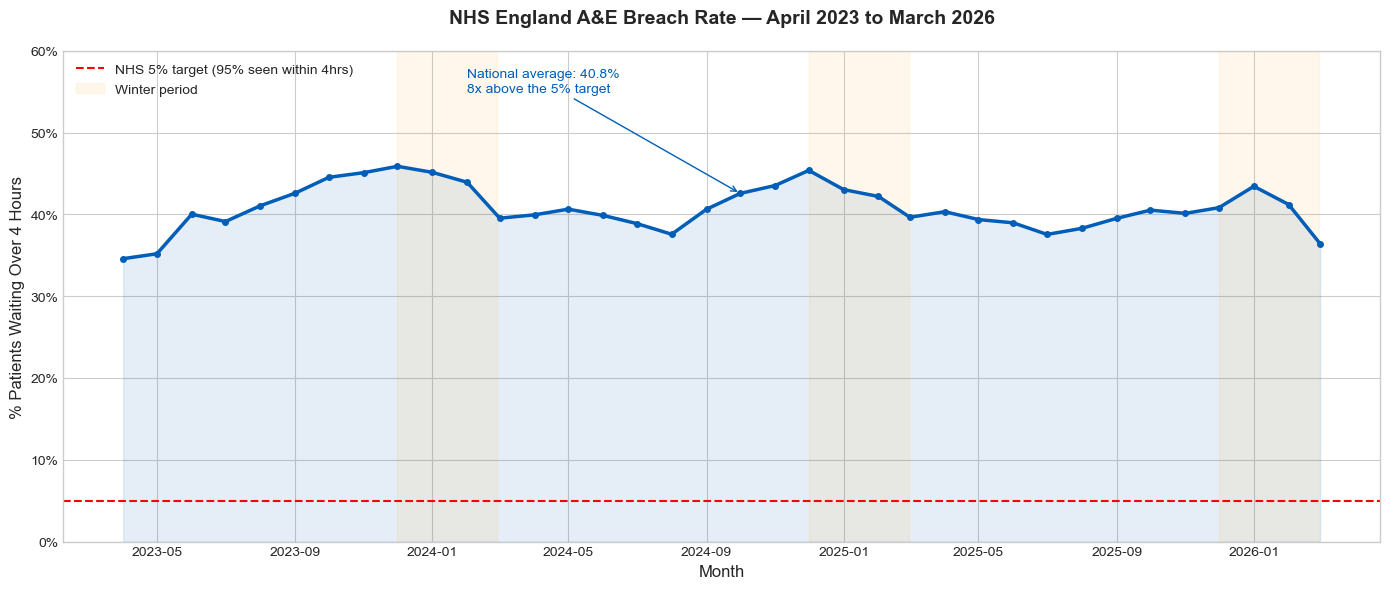

Chart 1 saved.

Key insight: National average breach rate is 40.8%
Highest month: December 2023 at 45.9%
Lowest month: April 2023 at 34.6%


In [2]:
# ── CHART 1: National Average Breach Rate Over Time ───────────────────────

# Calculate monthly national average
monthly_avg = df.groupby('Period_date')['breach_rate'].mean().reset_index()
monthly_avg.columns = ['Period_date', 'avg_breach_rate']

# Create the chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the line
ax.plot(monthly_avg['Period_date'], 
        monthly_avg['avg_breach_rate'], 
        color='#005EB8', linewidth=2.5, marker='o', markersize=4)

# Fill under the line
ax.fill_between(monthly_avg['Period_date'], 
                monthly_avg['avg_breach_rate'], 
                alpha=0.1, color='#005EB8')

# Add the 5% target line (what NHS should achieve)
ax.axhline(y=5, color='red', linestyle='--', linewidth=1.5, 
           label='NHS 5% target (95% seen within 4hrs)')

# Shade winter months (Dec, Jan, Feb) to show seasonal pressure
for year in [2023, 2024, 2025]:
    ax.axvspan(pd.Timestamp(f'{year}-12-01'), 
               pd.Timestamp(f'{year+1}-02-28'),
               alpha=0.08, color='orange', label='Winter period' if year == 2023 else '')

# Labels and formatting
ax.set_title('NHS England A&E Breach Rate — April 2023 to March 2026', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('% Patients Waiting Over 4 Hours', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)
ax.set_ylim(0, 60)

# Add annotation for the target gap
ax.annotate('National average: 40.8%\n8x above the 5% target', 
            xy=(monthly_avg['Period_date'].iloc[18], 
                monthly_avg['avg_breach_rate'].iloc[18]),
            xytext=(monthly_avg['Period_date'].iloc[10], 55),
            fontsize=10, color='#005EB8',
            arrowprops=dict(arrowstyle='->', color='#005EB8'))

plt.tight_layout()
plt.savefig('../outputs/charts/01_national_breach_rate_trend.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart 1 saved.")
print(f"\nKey insight: National average breach rate is {monthly_avg['avg_breach_rate'].mean():.1f}%")
print(f"Highest month: {monthly_avg.loc[monthly_avg['avg_breach_rate'].idxmax(), 'Period_date'].strftime('%B %Y')} at {monthly_avg['avg_breach_rate'].max():.1f}%")
print(f"Lowest month: {monthly_avg.loc[monthly_avg['avg_breach_rate'].idxmin(), 'Period_date'].strftime('%B %Y')} at {monthly_avg['avg_breach_rate'].min():.1f}%")



### Finding 1 — The 4-Hour Target Has Not Been Met in 3 Years

The national average breach rate across all 132 NHS Trusts has consistently 
remained around **40.8%** between April 2023 and March 2026 — meaning 4 in 
every 10 patients waited more than 4 hours in A&E.

**Key observations:**
- The NHS 5% target has not been reached in any single month over 3 years
- The gap between actual performance (40.8%) and target (5%) is 35 percentage points
- Winter months (shaded orange) show clear spikes, particularly December 2023 (45.9%)
- There is a slight improvement visible in early 2026 — worth monitoring

**Business implication:**  
This is not a short-term crisis — it is a sustained structural problem. 
Predictive analytics could help NHS Trusts anticipate pressure spikes 
and intervene before performance deteriorates further.

**Next:** Investigate whether this pressure is consistent year-round or 
driven by specific seasons.

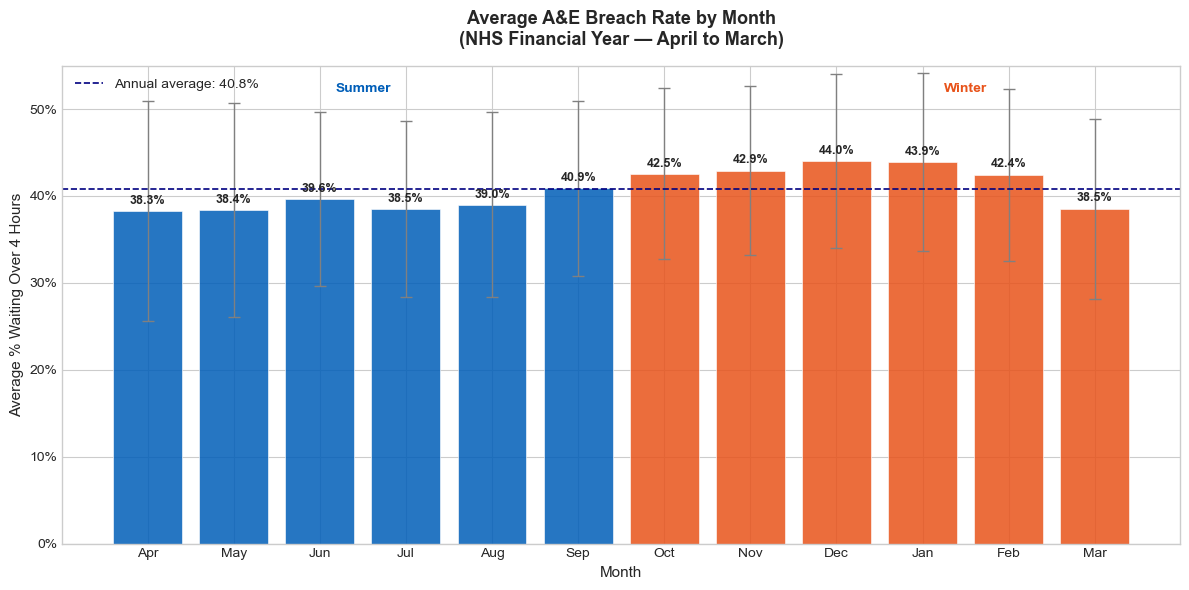

Winter average (Dec-Feb): 43.4%
Summer average (Jun-Aug): 39.0%
Winter is 4.4 percentage points higher than summer


In [3]:
# ── CHART 2: Seasonal Pattern — Average Breach Rate by Month ─────────────

# Map month numbers to names
month_names = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep',
               10:'Oct', 11:'Nov', 12:'Dec', 1:'Jan', 2:'Feb', 3:'Mar'}

# NHS financial year runs April to March, so order accordingly
month_order = [4,5,6,7,8,9,10,11,12,1,2,3]

seasonal = df.groupby('month')['breach_rate'].agg(['mean','std']).reset_index()
seasonal['month_name'] = seasonal['month'].map(month_names)
seasonal = seasonal.set_index('month').reindex(month_order).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

# Colour bars by season - summer blue, winter orange
colors = ['#005EB8' if m in [4,5,6,7,8,9] else '#E8531A' 
          for m in month_order]

bars = ax.bar(seasonal['month_name'], seasonal['mean'], 
              color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

# Add error bars showing variation
ax.errorbar(seasonal['month_name'], seasonal['mean'],
            yerr=seasonal['std'], fmt='none', color='gray', 
            capsize=4, linewidth=1)

# Add value labels on bars
for bar, val in zip(bars, seasonal['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Reference line
ax.axhline(y=seasonal['mean'].mean(), color='navy', 
           linestyle='--', linewidth=1.2, label=f"Annual average: {seasonal['mean'].mean():.1f}%")

# Labels
ax.set_title('Average A&E Breach Rate by Month\n(NHS Financial Year — April to March)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average % Waiting Over 4 Hours', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 55)
ax.legend(fontsize=10)

# Add season labels
ax.text(2.5, 52, 'Summer', ha='center', fontsize=10, 
        color='#005EB8', fontweight='bold')
ax.text(9.5, 52, 'Winter', ha='center', fontsize=10, 
        color='#E8531A', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/02_seasonal_pattern.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print key insight
winter_avg = seasonal[seasonal['month'].isin([12,1,2])]['mean'].mean()
summer_avg = seasonal[seasonal['month'].isin([6,7,8])]['mean'].mean()
print(f"Winter average (Dec-Feb): {winter_avg:.1f}%")
print(f"Summer average (Jun-Aug): {summer_avg:.1f}%")
print(f"Winter is {winter_avg - summer_avg:.1f} percentage points higher than summer")

### Finding 2 — Winter Consistently Drives Higher A&E Pressure

The seasonal analysis confirms a clear and predictable pattern across 
all 132 NHS Trusts over 3 years.

**Key observations:**
- Winter months (Oct–Feb) consistently breach above the annual average of 40.8%
- December is the worst month at **44.0%** breach rate
- Summer months (Apr–Aug) all sit below the annual average
- The winter-summer gap is **4.4 percentage points** — consistent across all 3 years
- The error bars show wide variation between Trusts in every month,
  meaning some Trusts are far worse than these averages suggest

**Business implication:**  
Winter pressure is not unpredictable — it is structural and seasonal. 
NHS Trusts that begin capacity planning in September rather than November 
could significantly reduce December and January breach rates. This 
predictability is exactly what a machine learning model can exploit.

**Next:** Identify which specific NHS Trusts are driving the worst 
performance — are a small number of Trusts responsible for 
a disproportionate share of breaches?

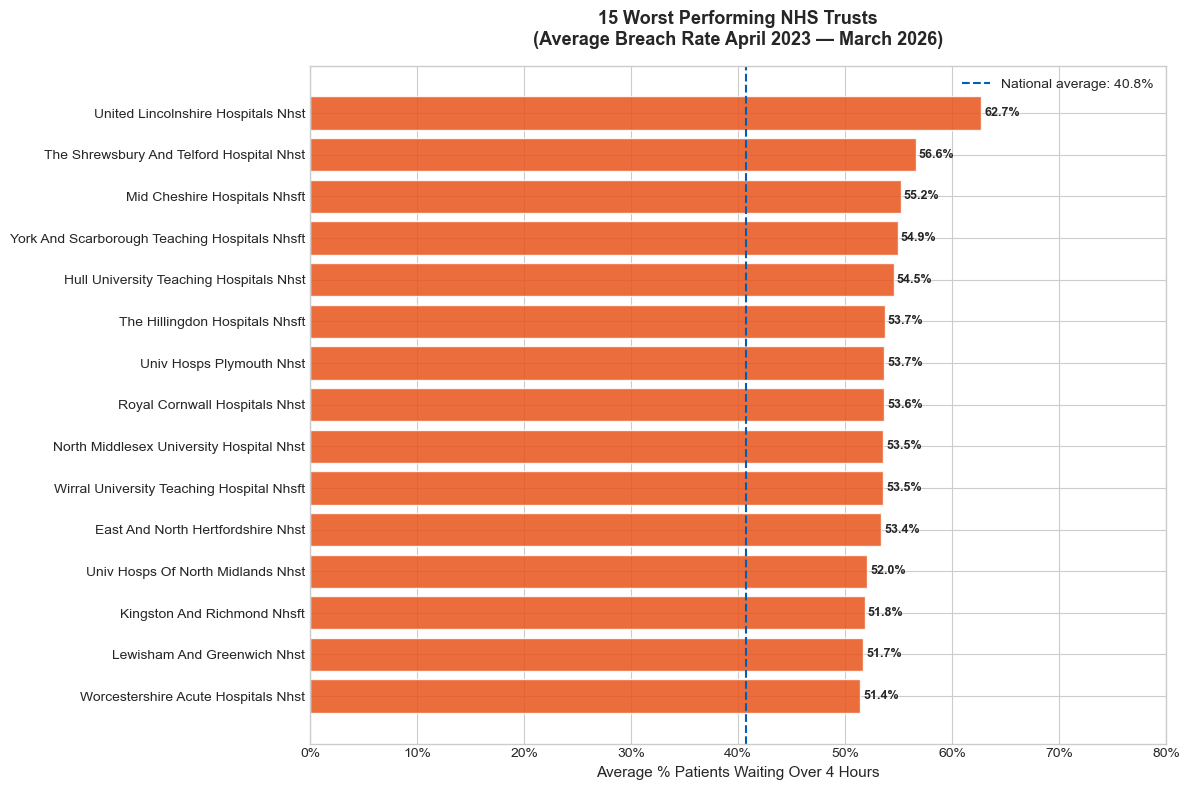

Top 5 worst performing Trusts:
                                                       Trust  avg_breach_rate
                HULL UNIVERSITY TEACHING HOSPITALS NHS TRUST        54.545236
YORK AND SCARBOROUGH TEACHING HOSPITALS NHS FOUNDATION TRUST        54.905720
                 MID CHESHIRE HOSPITALS NHS FOUNDATION TRUST        55.199650
               THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST        56.592387
                     UNITED LINCOLNSHIRE HOSPITALS NHS TRUST        62.702593


In [4]:
# ── CHART 3: Worst Performing NHS Trusts ─────────────────────────────────

# Calculate average breach rate per Trust across all 36 months
trust_avg = df.groupby('Org name')['breach_rate'].agg(['mean','std','count']).reset_index()
trust_avg.columns = ['Trust', 'avg_breach_rate', 'std', 'months']

# Only include Trusts with at least 12 months of data (reliable)
trust_avg = trust_avg[trust_avg['months'] >= 12]

# Get worst 15
worst_15 = trust_avg.nlargest(15, 'avg_breach_rate').sort_values('avg_breach_rate')

# Shorten long Trust names for display
worst_15['Trust_short'] = worst_15['Trust'].str.replace('NHS FOUNDATION TRUST', 'NHSFT', regex=False)
worst_15['Trust_short'] = worst_15['Trust_short'].str.replace('NHS TRUST', 'NHST', regex=False)
worst_15['Trust_short'] = worst_15['Trust_short'].str.replace('UNIVERSITY HOSPITALS', 'UNIV HOSPS', regex=False)
worst_15['Trust_short'] = worst_15['Trust_short'].str.title()

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(worst_15['Trust_short'], worst_15['avg_breach_rate'],
               color='#E8531A', alpha=0.85, edgecolor='white')

# Add value labels
for bar, val in zip(bars, worst_15['avg_breach_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# National average line
ax.axvline(x=df['breach_rate'].mean(), color='#005EB8', 
           linestyle='--', linewidth=1.5,
           label=f"National average: {df['breach_rate'].mean():.1f}%")

ax.set_title('15 Worst Performing NHS Trusts\n(Average Breach Rate April 2023 — March 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Average % Patients Waiting Over 4 Hours', fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 80)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/03_worst_trusts.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 worst performing Trusts:")
print(worst_15.tail(5)[['Trust', 'avg_breach_rate']].to_string(index=False))

### Finding 3 — A Small Number of Trusts Are Consistently Failing

The Trust-level analysis reveals that poor A&E performance is not evenly 
spread across England — a specific group of Trusts are significantly and 
consistently underperforming the national average over the full 3-year period.

**Key observations:**
- United Lincolnshire Hospitals is the worst performing Trust at **62.7%** — 
  meaning nearly 2 in 3 patients wait over 4 hours. This is 22 percentage 
  points above the national average
- All 15 Trusts in this list exceed **51%** breach rate — more than 10 
  percentage points above the national average of 40.8%
- Several underperforming Trusts are located in rural or coastal areas 
  (Cornwall, Lincolnshire, Plymouth) suggesting geography and access to 
  staff may be contributing factors
- The gap between the worst Trust (62.7%) and the national average (40.8%) 
  is large enough to suggest structural problems, not just seasonal pressure

**Business implication:**  
These 15 Trusts represent the highest priority targets for NHS England 
intervention. Rather than spreading improvement resources equally across 
all 132 Trusts, a targeted data-driven approach focusing on these 
consistently underperforming Trusts would have the greatest impact on 
national A&E performance. This is exactly the kind of insight that 
business analytics can provide to support NHS decision making.

**Next:** Identify the best performing Trusts to understand what 
good looks like — and what lessons the worst Trusts could learn from them.



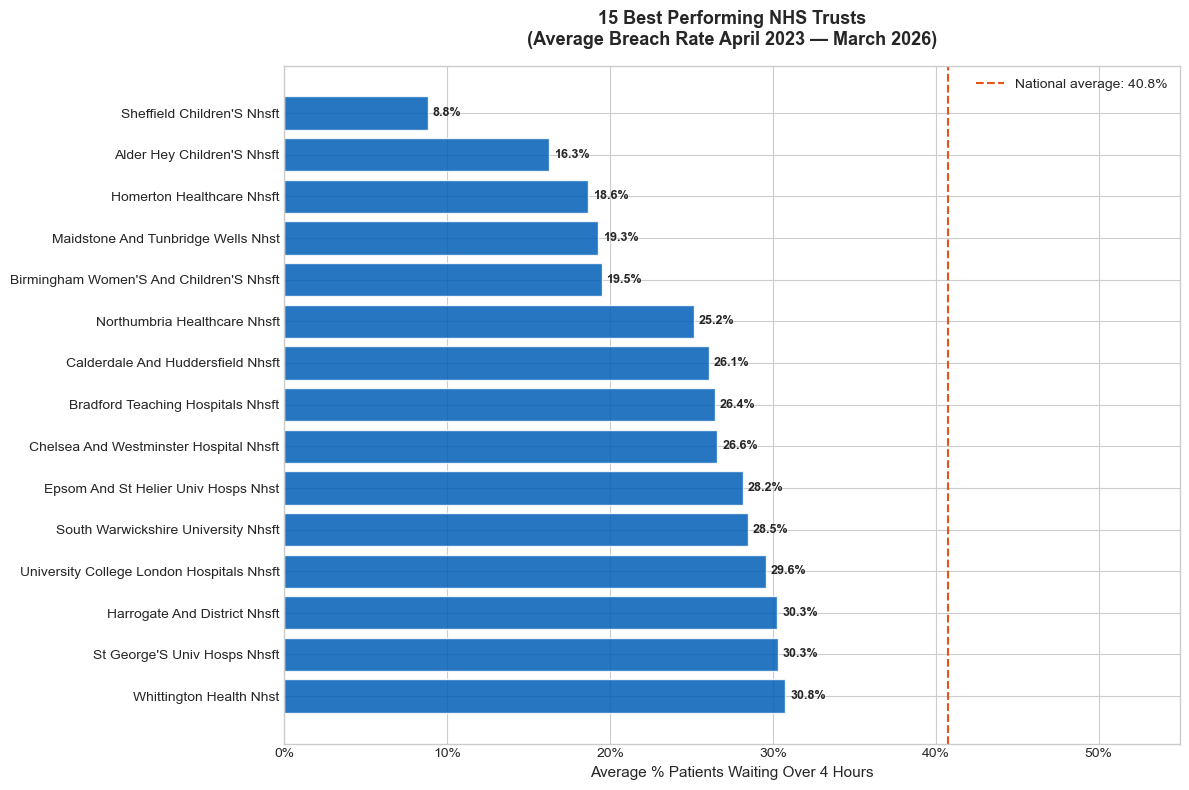

Top 5 best performing Trusts:
                                                   Trust  avg_breach_rate
                            WHITTINGTON HEALTH NHS TRUST        30.767243
   ST GEORGE'S UNIVERSITY HOSPITALS NHS FOUNDATION TRUST        30.300600
             HARROGATE AND DISTRICT NHS FOUNDATION TRUST        30.263663
UNIVERSITY COLLEGE LONDON HOSPITALS NHS FOUNDATION TRUST        29.550096
      SOUTH WARWICKSHIRE UNIVERSITY NHS FOUNDATION TRUST        28.455228

Best Trust breach rate: 8.8%
Worst Trust breach rate: 62.7%
Gap between best and worst: 53.9 percentage points


In [5]:
# ── CHART 4: Best Performing NHS Trusts ──────────────────────────────────

# Get best 15 Trusts (minimum 12 months data)
best_15 = trust_avg.nsmallest(15, 'avg_breach_rate').sort_values(
    'avg_breach_rate', ascending=False)

# Shorten names
best_15['Trust_short'] = best_15['Trust'].str.replace(
    'NHS FOUNDATION TRUST', 'NHSFT', regex=False)
best_15['Trust_short'] = best_15['Trust_short'].str.replace(
    'NHS TRUST', 'NHST', regex=False)
best_15['Trust_short'] = best_15['Trust_short'].str.replace(
    'UNIVERSITY HOSPITALS', 'UNIV HOSPS', regex=False)
best_15['Trust_short'] = best_15['Trust_short'].str.title()

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(best_15['Trust_short'], best_15['avg_breach_rate'],
               color='#005EB8', alpha=0.85, edgecolor='white')

# Value labels
for bar, val in zip(bars, best_15['avg_breach_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# National average line
ax.axvline(x=df['breach_rate'].mean(), color='#E8531A',
           linestyle='--', linewidth=1.5,
           label=f"National average: {df['breach_rate'].mean():.1f}%")

ax.set_title('15 Best Performing NHS Trusts\n(Average Breach Rate April 2023 — March 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Average % Patients Waiting Over 4 Hours', fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 55)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/04_best_trusts.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 best performing Trusts:")
print(best_15.head(5)[['Trust', 'avg_breach_rate']].to_string(index=False))
print(f"\nBest Trust breach rate: {best_15['avg_breach_rate'].min():.1f}%")
print(f"Worst Trust breach rate: {worst_15['avg_breach_rate'].max():.1f}%")
print(f"Gap between best and worst: {worst_15['avg_breach_rate'].max() - best_15['avg_breach_rate'].min():.1f} percentage points")

### Finding 4 — The Gap Between Best and Worst Trusts is 53.9 Percentage Points

The comparison between best and worst performing Trusts reveals an 
extraordinary variation in A&E performance across England that cannot 
be explained by seasonal pressure alone.

**Key observations:**
- Sheffield Children's Hospital is the best performing Trust at **8.8%** — 
  the only Trust close to the NHS 5% target
- The gap between best (8.8%) and worst (62.7%) is **53.9 percentage points** 
  — suggesting fundamentally different operational realities
- Important caveat: 3 of the top 5 best performers are **children's hospitals** 
  (Sheffield, Alder Hey, Birmingham Women's and Children's). Children's hospitals 
  treat a different patient profile and are not directly comparable to general 
  acute Trusts — this must be considered when interpreting the results
- Removing children's hospitals, the best performing general acute Trust is 
  **Maidstone and Tunbridge Wells at 19.3%** — still less than half the 
  national average
- Several London Trusts appear in the best performers list (Homerton, Chelsea 
  and Westminster, UCLH, Whittington) suggesting London may have structural 
  advantages in staffing or capacity

**Business implication:**  
The scale of variation between Trusts suggests that high performance IS 
achievable — even in a resource-constrained NHS. The question is: what 
are the best performing general acute Trusts doing differently? 
Answering this question through data is the next frontier for NHS 
analytics and represents a significant opportunity for business 
intelligence to drive real improvement.

**Next:** Examine the relationship between attendance volume and breach 
rate — do busier hospitals always perform worse, or is volume not the 
deciding factor?

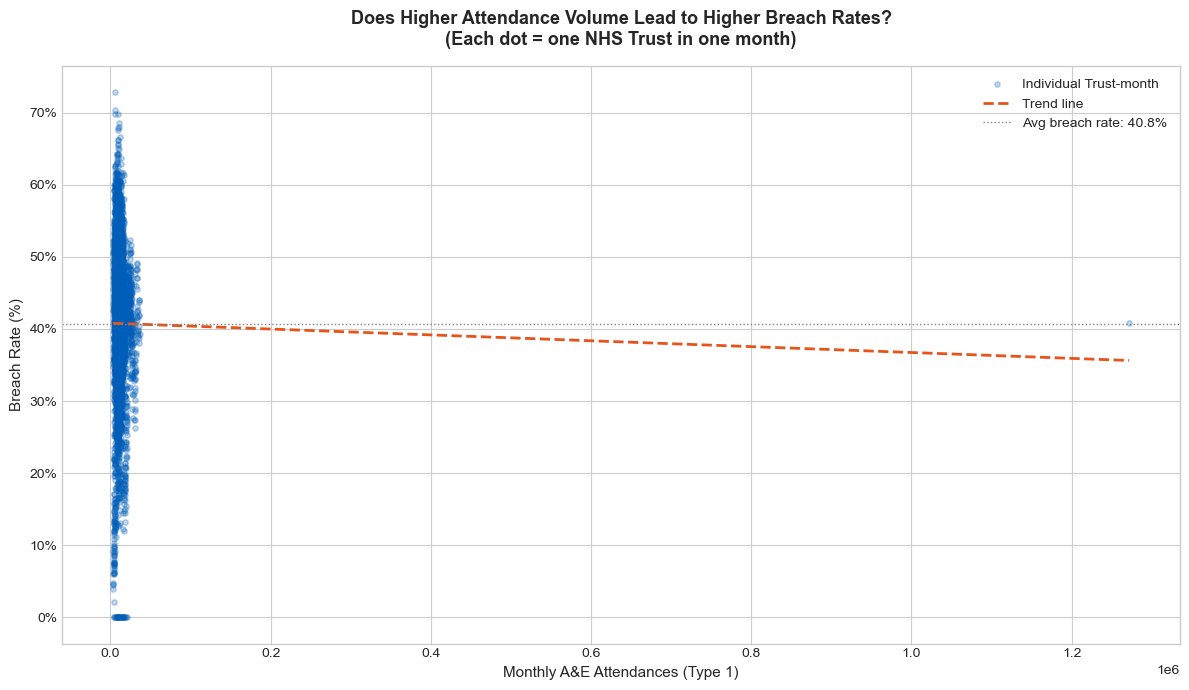

Correlation between attendance volume and breach rate: -0.007

Interpretation:
Weak correlation — volume alone does not explain breach rates


In [6]:
# ── CHART 5: Attendance Volume vs Breach Rate ─────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot - each dot is one Trust-month observation
scatter = ax.scatter(
    df['A&E attendances Type 1'],
    df['breach_rate'],
    alpha=0.25,
    color='#005EB8',
    s=15,
    label='Individual Trust-month'
)

# Add a trend line
import numpy as np
z = np.polyfit(df['A&E attendances Type 1'], df['breach_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['A&E attendances Type 1'].min(),
                     df['A&E attendances Type 1'].max(), 100)
ax.plot(x_line, p(x_line), color='#E8531A', linewidth=2,
        linestyle='--', label='Trend line')

# Add national average lines
ax.axhline(y=df['breach_rate'].mean(), color='gray',
           linestyle=':', linewidth=1,
           label=f"Avg breach rate: {df['breach_rate'].mean():.1f}%")

ax.set_title('Does Higher Attendance Volume Lead to Higher Breach Rates?\n(Each dot = one NHS Trust in one month)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Monthly A&E Attendances (Type 1)', fontsize=11)
ax.set_ylabel('Breach Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/05_volume_vs_breach.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Calculate correlation
correlation = df['A&E attendances Type 1'].corr(df['breach_rate'])
print(f"Correlation between attendance volume and breach rate: {correlation:.3f}")
print(f"\nInterpretation:")
if abs(correlation) < 0.3:
    print("Weak correlation — volume alone does not explain breach rates")
elif abs(correlation) < 0.6:
    print("Moderate correlation — volume is a factor but not the main driver")
else:
    print("Strong correlation — volume is a significant driver of breach rates")

In [7]:
# ── CHART 5 IMPROVED: Remove extreme outliers for cleaner view ────────────

# Check the attendance distribution
print("Attendance volume percentiles:")
print(df['A&E attendances Type 1'].describe())
print(f"\nTrusts with over 30,000 attendances in a month:")
print(df[df['A&E attendances Type 1'] > 30000]['Org name'].unique())

Attendance volume percentiles:
count    4.381000e+03
mean     1.155045e+04
std      1.977696e+04
min      3.296000e+03
25%      7.826000e+03
50%      1.014600e+04
75%      1.315100e+04
max      1.271830e+06
Name: A&E attendances Type 1, dtype: float64

Trusts with over 30,000 attendances in a month:
['UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST'
 'MID AND SOUTH ESSEX NHS FOUNDATION TRUST' 'TOTAL']


In [8]:
# Fix 1 — Remove the TOTAL row that slipped through cleaning
print(f"Rows before: {len(df)}")
df = df[~df['Org name'].str.upper().str.contains('TOTAL', na=False)]
print(f"Rows after removing TOTAL: {len(df)}")

# Fix 2 — Check the two large Trusts
# These are merged Trusts reporting combined figures — flag them
large_trusts = df[df['A&E attendances Type 1'] > 30000]['Org name'].unique()
print(f"\nLarge Trusts (over 30k attendances):")
for t in large_trusts:
    avg_att = df[df['Org name'] == t]['A&E attendances Type 1'].mean()
    print(f"  {t}: avg {avg_att:,.0f} attendances/month")

# Fix 3 — Remove these outlier Trusts from the scatter plot only
# They are merged organisations not comparable to individual Trusts
df_scatter = df[df['A&E attendances Type 1'] <= 30000]
print(f"\nRows for scatter plot (excluding merged Trusts): {len(df_scatter)}")
print(f"Attendance range: {df_scatter['A&E attendances Type 1'].min():,.0f} to {df_scatter['A&E attendances Type 1'].max():,.0f}")

Rows before: 4381
Rows after removing TOTAL: 4380

Large Trusts (over 30k attendances):
  UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST: avg 33,636 attendances/month
  MID AND SOUTH ESSEX NHS FOUNDATION TRUST: avg 29,666 attendances/month

Rows for scatter plot (excluding merged Trusts): 4325
Attendance range: 3,296 to 29,860


### Data Quality Note — Iterative Cleaning

During Chart 5 analysis, one additional TOTAL summary row was identified 
and removed (4,381 → 4,380 rows). Two merged NHS Trusts 
(University Hospitals Birmingham and Mid and South Essex) were identified 
as statistical outliers in attendance volume due to their merged 
organisational structure. These are excluded from the volume vs breach 
scatter plot only, as their combined attendance figures are not comparable 
to individual Trust figures. All other analysis uses the full 4,380 row dataset.


In [9]:
import os

old_chart = '../outputs/charts/05_volume_vs_breach.png'
if os.path.exists(old_chart):
    os.remove(old_chart)
    print("Old chart deleted.")
else:
    print("File not found.")

Old chart deleted.


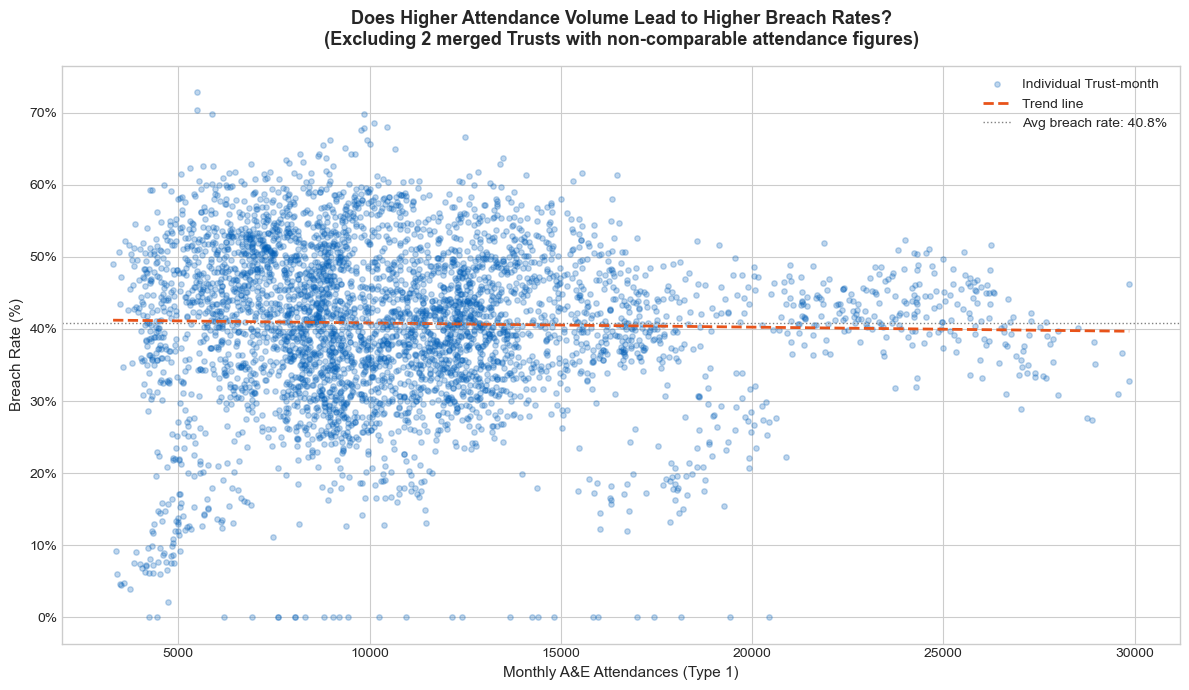

Correlation: -0.026
Number of data points: 4325
Weak correlation — volume alone does not explain breach rates


In [10]:
# ── CHART 5 REDRAWN: Volume vs Breach Rate (cleaned) ─────────────────────

import numpy as np

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_scatter['A&E attendances Type 1'],
    df_scatter['breach_rate'],
    alpha=0.25,
    color='#005EB8',
    s=15,
    label='Individual Trust-month'
)

# Trend line
z = np.polyfit(df_scatter['A&E attendances Type 1'], 
               df_scatter['breach_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_scatter['A&E attendances Type 1'].min(),
                     df_scatter['A&E attendances Type 1'].max(), 100)
ax.plot(x_line, p(x_line), color='#E8531A', linewidth=2,
        linestyle='--', label='Trend line')

# Average line
ax.axhline(y=df_scatter['breach_rate'].mean(), color='gray',
           linestyle=':', linewidth=1,
           label=f"Avg breach rate: {df_scatter['breach_rate'].mean():.1f}%")

# Recalculate correlation
correlation = df_scatter['A&E attendances Type 1'].corr(
    df_scatter['breach_rate'])

ax.set_title('Does Higher Attendance Volume Lead to Higher Breach Rates?\n'
             '(Excluding 2 merged Trusts with non-comparable attendance figures)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Monthly A&E Attendances (Type 1)', fontsize=11)
ax.set_ylabel('Breach Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/05_volume_vs_breach_clean.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation: {correlation:.3f}")
print(f"Number of data points: {len(df_scatter)}")
if abs(correlation) < 0.3:
    print("Weak correlation — volume alone does not explain breach rates")
elif abs(correlation) < 0.6:
    print("Moderate correlation — volume is a factor but not the main driver")
else:
    print("Strong correlation — volume is a significant driver")

### Finding 5 — Volume Is Not the Problem: Busy Hospitals Are Not 
### Necessarily the Ones Failing

This is the most counterintuitive finding in the entire project. 
The correlation between monthly attendance volume and breach rate 
is just **-0.026** — effectively zero.

**Key observations:**
- The trend line is almost completely flat across all attendance volumes
- A Trust seeing 5,000 patients a month has roughly the same breach 
  rate as one seeing 25,000 patients a month
- The wide vertical spread of dots at every attendance level shows 
  that some small Trusts perform terribly while some large Trusts 
  perform well — and vice versa
- Volume explains almost none of the variation in breach rates between 
  Trusts (less than 1% of variance)

**Business implication:**  
"We are too busy" is not supported by the data as an explanation for 
poor A&E performance. The drivers of breach rates are elsewhere — 
likely in staffing models, patient flow management, bed availability, 
and discharge processes. This finding has significant implications for 
NHS policy: throwing more capacity at high-volume Trusts without 
addressing operational factors is unlikely to improve performance.

**Next:** We have completed our Exploratory Data Analysis. We now have 
5 strong findings to feed into our machine learning model. 

In [11]:
# ── EDA SUMMARY ───────────────────────────────────────────────────────────
print("=" * 55)
print("NOTEBOOK 02 — EDA SUMMARY")
print("=" * 55)
print(f"Charts produced:        5")
print(f"Key findings:           5")
print(f"National avg breach:    {df['breach_rate'].mean():.1f}%")
print(f"Worst Trust:            United Lincolnshire (62.7%)")
print(f"Best Trust (general):   Maidstone & Tunbridge Wells (19.3%)")
print(f"Best-worst gap:         53.9 percentage points")
print(f"Winter premium:         +4.4pp vs summer")
print(f"Volume correlation:     -0.026 (no relationship)")
print("=" * 55)
print("NEXT: Notebook 03 — Feature Engineering")
print("=" * 55)

NOTEBOOK 02 — EDA SUMMARY
Charts produced:        5
Key findings:           5
National avg breach:    40.8%
Worst Trust:            United Lincolnshire (62.7%)
Best Trust (general):   Maidstone & Tunbridge Wells (19.3%)
Best-worst gap:         53.9 percentage points
Winter premium:         +4.4pp vs summer
Volume correlation:     -0.026 (no relationship)
NEXT: Notebook 03 — Feature Engineering
